# Preference Drift on Memo2496 IEEE DataPort

## Section 0 — Imports and settings

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import f_classif
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score,
)
from sklearn.metrics.pairwise import cosine_similarity

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
SEQ_LEN = 10
N_SEQUENCES = 800
K_NEIGHBORS = 8
JUMP_PROB = 0.2
LSTM_UNITS = 64
DENSE_UNITS = 32
TRANSFORMER_D_MODEL = 64
TRANSFORMER_NUM_HEADS = 4
TRANSFORMER_FF_DIM = 64
EPOCHS = 60
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
EARLY_STOP_PATIENCE = 8
TEST_SIZE = 0.30
VAL_TEST_SPLIT = 0.50
RESULTS_DIR = "results"
ANNOTATIONS_DIR = "Annotations"

np.random.seed(SEED)
tf.random.set_seed(SEED)
print("TensorFlow version:", tf.__version__)
print("Setup OK.")

2026-08-13 19:29:01.059847: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.16.2
Setup OK.


/opt/anaconda3/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
print("Current working directory:", os.getcwd())
print("Annotations folder found?", os.path.isdir(ANNOTATIONS_DIR))
if os.path.isdir(ANNOTATIONS_DIR):
    print("Files inside:", sorted(os.listdir(ANNOTATIONS_DIR)))

Current working directory: /Users/mayurkulkarni/Music Preference Drift
Annotations folder found? True
Files inside: ['arousal_all_average.csv', 'arousal_all_std.csv', 'songs_info_all.csv', 'valence_all_average.csv', 'valence_all_std.csv']


## Section 1 — Load Files and Extract Features from the Valence/Arousal Time Series



In [3]:
songs_info = pd.read_csv(os.path.join(ANNOTATIONS_DIR, "songs_info_all.csv"))
val_avg = pd.read_csv(os.path.join(ANNOTATIONS_DIR, "valence_all_average.csv"))
aro_avg = pd.read_csv(os.path.join(ANNOTATIONS_DIR, "arousal_all_average.csv"))
val_std = pd.read_csv(os.path.join(ANNOTATIONS_DIR, "valence_all_std.csv"))
aro_std = pd.read_csv(os.path.join(ANNOTATIONS_DIR, "arousal_all_std.csv"))

print("songs_info_all.csv:", songs_info.shape)
print("valence_all_average.csv:", val_avg.shape)
print("arousal_all_average.csv:", aro_avg.shape)
sample_cols = [c for c in val_avg.columns if c.startswith("sample_")]
print(f"\n{len(sample_cols)} time-sample columns found (one per second, 0 to {len(sample_cols)-1} sec)")

songs_info_all.csv: (2496, 7)
valence_all_average.csv: (2496, 302)
arousal_all_average.csv: (2496, 302)

301 time-sample columns found (one per second, 0 to 300 sec)


In [4]:
def extract_features(df, prefix, sample_cols):
    """For each song (row), compute 8 summary statistics from its valence/arousal
    curve over time: mean, std, min, max, range, first value, last valid value, trend (slope)."""
    vals = df[sample_cols].values
    feats = {}
    feats[f"{prefix}_mean"] = np.nanmean(vals, axis=1)
    feats[f"{prefix}_std"] = np.nanstd(vals, axis=1)
    feats[f"{prefix}_min"] = np.nanmin(vals, axis=1)
    feats[f"{prefix}_max"] = np.nanmax(vals, axis=1)
    feats[f"{prefix}_range"] = feats[f"{prefix}_max"] - feats[f"{prefix}_min"]
    feats[f"{prefix}_first"] = vals[:, 0]

    last_vals = []
    for row in vals:
        valid = row[~np.isnan(row)]
        last_vals.append(valid[-1] if len(valid) > 0 else np.nan)
    feats[f"{prefix}_last"] = np.array(last_vals)

    slopes = []
    for row in vals:
        valid_idx = np.where(~np.isnan(row))[0]
        slopes.append(np.polyfit(valid_idx, row[valid_idx], 1)[0] if len(valid_idx) >= 2 else 0.0)
    feats[f"{prefix}_trend"] = np.array(slopes)

    feats[f"{prefix}_n_valid"] = (~np.isnan(vals)).sum(axis=1)
    return pd.DataFrame(feats)

val_feats = extract_features(val_avg, "valence", sample_cols)
aro_feats = extract_features(aro_avg, "arousal", sample_cols)

# Add mean annotator disagreement (from the _std files) as two more features
val_feats["valence_annot_disagreement"] = np.nanmean(val_std[sample_cols].values, axis=1)
aro_feats["arousal_annot_disagreement"] = np.nanmean(aro_std[sample_cols].values, axis=1)

feat_df = pd.concat([val_avg[["song_id"]], val_feats, aro_feats], axis=1)
print("Feature table shape:", feat_df.shape)
print("Any missing values?", feat_df.isnull().sum().sum())
feat_df.head()

Feature table shape: (2496, 21)
Any missing values? 0


,song_id,valence_mean,valence_std,valence_min,valence_max,valence_range,valence_first,valence_last,valence_trend,valence_n_valid,...,arousal_mean,arousal_std,arousal_min,arousal_max,arousal_range,arousal_first,arousal_last,arousal_trend,arousal_n_valid,arousal_annot_disagreement
0,1,-0.006951,0.098628,-0.267700,0.265800,0.533500,-0.186600,0.011400,0.000401,237,...,0.423102,0.256200,-0.085700,0.731800,0.817500,0.200300,-0.029200,-0.000008,237,0.407486
1,2,0.179976,0.124787,-0.275111,0.370444,0.645556,-0.275111,-0.002889,0.002380,101,...,0.451895,0.113015,-0.011333,0.583111,0.594444,-0.011333,0.218111,0.001814,101,0.504380
2,3,-0.096202,0.042488,-0.216875,0.019375,0.236250,-0.216875,-0.118875,-0.001905,50,...,0.167163,0.099164,-0.082875,0.293375,0.376250,-0.036625,0.293375,0.006218,50,0.498310
3,4,0.265359,0.109758,0.005222,0.444111,0.438889,0.009111,0.027444,0.001766,102,...,0.294723,0.202032,-0.131889,0.558667,0.690556,-0.131889,-0.098556,0.000881,102,0.334378
4,5,-0.070485,0.103095,-0.249875,0.139000,0.388875,-0.012250,-0.028625,-0.000615,246,...,-0.201600,0.120064,-0.427875,0.034625,0.462500,-0.006625,-0.173500,0.000152,246,0.389085


## Section 2 — Map Emotion Labels onto 4 Classes

In [5]:
EMOTION_MAP = {
    "Excited": "happy", "Delighted": "happy", "Happy": "happy",
    "Tense": "angry", "Angry": "angry", "Frustrated": "angry",
    "Depressed": "sad", "Bored": "sad", "Tired": "sad",
    "Relaxed": "relax", "Content": "relax", "Calm": "relax",
}
songs_info["Class"] = songs_info["emotion"].map(EMOTION_MAP)
print("Unmapped rows (should be 0):", songs_info["Class"].isnull().sum())

df = pd.merge(feat_df, songs_info[["song_id", "Class"]], on="song_id", how="inner")
print("\nFinal merged shape:", df.shape)
print(df["Class"].value_counts())

label_col = "Class"
feature_cols = [c for c in df.columns if c not in ("song_id", label_col)]
print(f"\n{len(feature_cols)} feature columns")
df.head()

Unmapped rows (should be 0): 0

Final merged shape: (2496, 22)
Class
relax    757
happy    754
sad      611
angry    374
Name: count, dtype: int64

20 feature columns


,song_id,valence_mean,valence_std,valence_min,valence_max,valence_range,valence_first,valence_last,valence_trend,valence_n_valid,...,arousal_std,arousal_min,arousal_max,arousal_range,arousal_first,arousal_last,arousal_trend,arousal_n_valid,arousal_annot_disagreement,Class
0,1,-0.006951,0.098628,-0.267700,0.265800,0.533500,-0.186600,0.011400,0.000401,237,...,0.256200,-0.085700,0.731800,0.817500,0.200300,-0.029200,-0.000008,237,0.407486,angry
1,2,0.179976,0.124787,-0.275111,0.370444,0.645556,-0.275111,-0.002889,0.002380,101,...,0.113015,-0.011333,0.583111,0.594444,-0.011333,0.218111,0.001814,101,0.504380,happy
2,3,-0.096202,0.042488,-0.216875,0.019375,0.236250,-0.216875,-0.118875,-0.001905,50,...,0.099164,-0.082875,0.293375,0.376250,-0.036625,0.293375,0.006218,50,0.498310,angry
3,4,0.265359,0.109758,0.005222,0.444111,0.438889,0.009111,0.027444,0.001766,102,...,0.202032,-0.131889,0.558667,0.690556,-0.131889,-0.098556,0.000881,102,0.334378,happy
4,5,-0.070485,0.103095,-0.249875,0.139000,0.388875,-0.012250,-0.028625,-0.000615,246,...,0.120064,-0.427875,0.034625,0.462500,-0.006625,-0.173500,0.000152,246,0.389085,sad


## Section 3 — Emotional Feature Analysis

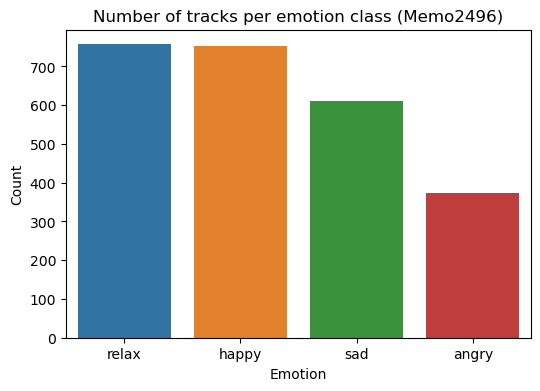

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x=label_col, order=df[label_col].value_counts().index)
plt.title("Number of tracks per emotion class (Memo2496)")
plt.xlabel("Emotion"); plt.ylabel("Count")
plt.show()

Top 4 most emotion-discriminative features:
  arousal_mean                   F-score= 2086.51
  arousal_last                   F-score= 1693.94
  valence_mean                   F-score= 1640.48
  arousal_max                    F-score= 1581.63


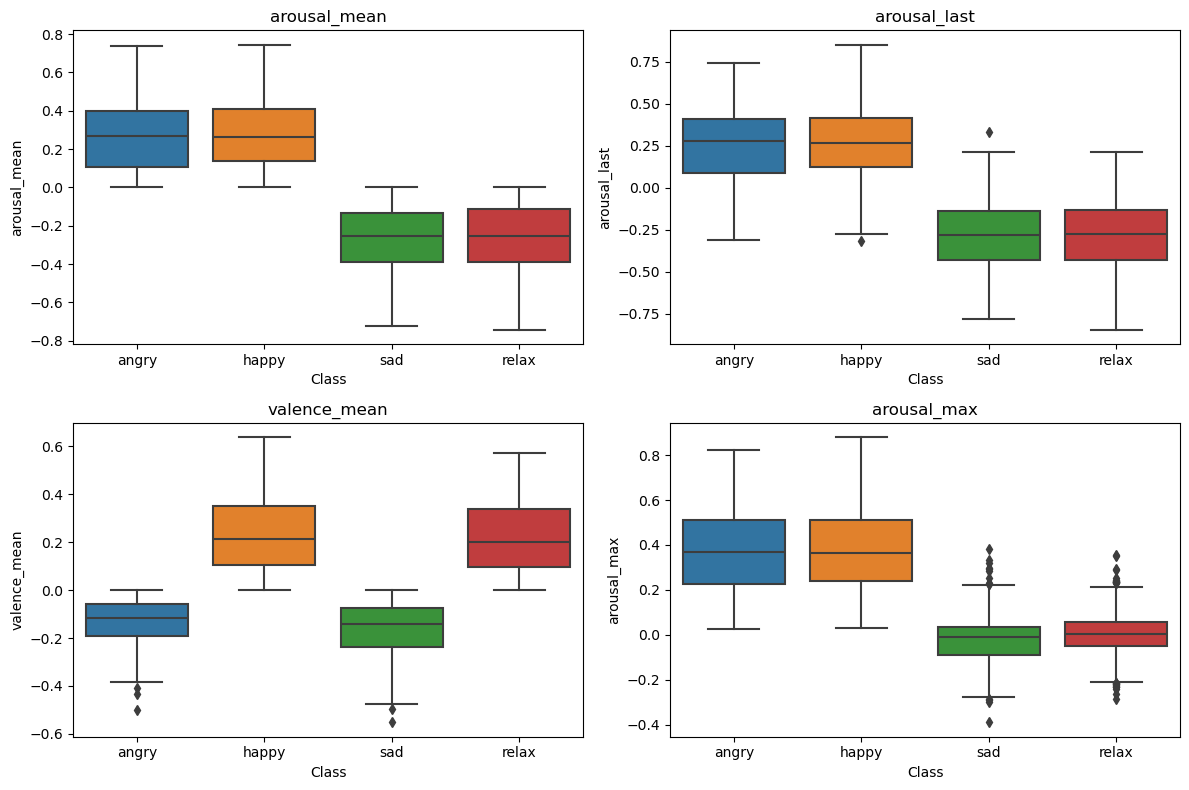

In [7]:
_y_viz = LabelEncoder().fit_transform(df[label_col].values)
_X_viz = df[feature_cols].values
f_scores, p_values = f_classif(_X_viz, _y_viz)
ranked = sorted(zip(feature_cols, f_scores), key=lambda x: -x[1])
top_features = [name for name, score in ranked[:4]]
print("Top 4 most emotion-discriminative features:")
for name, score in ranked[:4]:
    print(f"  {name:30s} F-score={score:8.2f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.flatten(), top_features):
    sns.boxplot(data=df, x=label_col, y=feat, ax=ax)
    ax.set_title(feat)
plt.tight_layout()
plt.show()

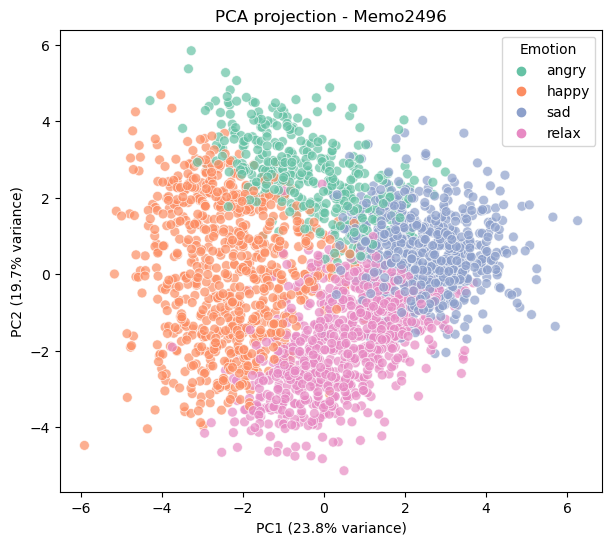

Explained variance by 2 PCs: 0.4358786011758007


In [8]:
scaler_viz = StandardScaler()
X_scaled_viz = scaler_viz.fit_transform(_X_viz)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_viz)

plt.figure(figsize=(7,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df[label_col], palette='Set2', s=50, alpha=0.7)
plt.title("PCA projection - Memo2496")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend(title="Emotion")
plt.show()
print("Explained variance by 2 PCs:", pca.explained_variance_ratio_.sum())

## Section 4 — Preprocessing

In [9]:
X_raw = df[feature_cols].values
y_raw = df[label_col].values

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)
print("Classes:", list(label_encoder.classes_))

feature_scaler = StandardScaler()
X_scaled = feature_scaler.fit_transform(X_raw)
print("X_scaled shape:", X_scaled.shape)

Classes: ['angry', 'happy', 'relax', 'sad']
X_scaled shape: (2496, 20)


## Section 5 — Sequence Construction

Same simulated-session approach as the Turkish dataset: mostly move to an acoustically/emotionally
similar track, with occasional random jumps.

In [10]:
def _fit_nearest_neighbors(X, k):
    nn_model = NearestNeighbors(n_neighbors=k + 1, algorithm="ball_tree").fit(X)
    _, neighbor_idx = nn_model.kneighbors(X)
    return neighbor_idx

def build_chained_sequences(X, y, seq_len, n_sequences, k_neighbors=8, jump_prob=0.2, seed=0):
    neighbor_idx = _fit_nearest_neighbors(X, k_neighbors)
    rng = np.random.default_rng(seed)
    n = len(X)
    seqs_X, seqs_y = [], []
    for _ in range(n_sequences):
        current = rng.integers(0, n)
        chain = [current]
        for _ in range(seq_len - 1):
            if rng.random() < jump_prob:
                nxt = rng.integers(0, n)
            else:
                candidates = neighbor_idx[current][1:]
                nxt = rng.choice(candidates)
            chain.append(nxt); current = nxt
        seqs_X.append(X[chain]); seqs_y.append(y[chain])
    return np.array(seqs_X), np.array(seqs_y)

X_seq, y_seq = build_chained_sequences(X_scaled, y, SEQ_LEN, N_SEQUENCES,
                                        k_neighbors=K_NEIGHBORS, jump_prob=JUMP_PROB, seed=SEED)
print("Sequence shapes:", X_seq.shape, y_seq.shape)

Sequence shapes: (800, 10, 20) (800, 10)


## Section 6 — Train / Validation / Test Split

In [11]:
X_train, X_temp, y_train, y_temp = train_test_split(X_seq, y_seq, test_size=TEST_SIZE, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=VAL_TEST_SPLIT, random_state=SEED)
print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)
N_FEATURES = X_train.shape[2]
N_CLASSES = len(label_encoder.classes_)

Train: (560, 10, 20)  Val: (120, 10, 20)  Test: (120, 10, 20)


## Section 7 — LSTM + Attention and Transformer Models

In [12]:
def build_lstm_attention_model(seq_len, n_features, n_classes, lstm_units=64, dense_units=32):
    inputs = keras.Input(shape=(seq_len, n_features), name="sequence_input")
    x = layers.TimeDistributed(layers.Dense(dense_units, activation="relu"), name="feature_projection")(inputs)
    lstm_out = layers.Bidirectional(layers.LSTM(lstm_units, return_sequences=True), name="bilstm")(x)
    attention_scores = layers.Dense(1, activation="tanh", name="attention_score")(lstm_out)
    attention_weights = layers.Softmax(axis=1, name="attention_weights")(attention_scores)
    context_vector = layers.Multiply(name="attention_context")([lstm_out, attention_weights])
    representation = layers.TimeDistributed(layers.Dense(dense_units, activation="relu"), name="dense_representation")(context_vector)
    outputs = layers.TimeDistributed(layers.Dense(n_classes, activation="softmax"), name="prediction_output")(representation)
    model = keras.Model(inputs=inputs, outputs=outputs, name="LSTM_Attention_Memo2496")
    repr_model = keras.Model(inputs=inputs, outputs=[representation, attention_weights], name="lstm_repr_extractor")
    return model, repr_model

lstm_model, lstm_repr_model = build_lstm_attention_model(SEQ_LEN, N_FEATURES, N_CLASSES, LSTM_UNITS, DENSE_UNITS)
lstm_model.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                    loss="sparse_categorical_crossentropy", metrics=["accuracy"])
lstm_model.summary()

Model: "LSTM_Attention_Memo2496"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 10, 20)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_projection  │ (None, 10, 32)    │        672 │ sequence_input[0… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm              │ (None, 10, 128)   │     49,664 │ feature_projecti… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_score     │ (None, 10, 1)     │        129 │ bilstm[0][0]      │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_weights   │ (None, 10, 1)     │          0 │ attention_score[… │
│ (Softmax)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_context   │ (None, 10, 128)   │          0 │ bilstm[0][0],     │
│ (Multiply)          │                   │            │ attention_weight… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_representati… │ (None, 10, 32)    │      4,128 │ attention_contex… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prediction_output   │ (None, 10, 4)     │        132 │ dense_representa… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 54,725 (213.77 KB)

 Trainable params: 54,725 (213.77 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
def _transformer_encoder_block(x, head_size, num_heads, ff_dim, dropout=0.1):
    attn_out = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    attn_out = layers.Dropout(dropout)(attn_out)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_out)
    ff_out = layers.Dense(ff_dim, activation="relu")(out1)
    ff_out = layers.Dense(x.shape[-1])(ff_out)
    ff_out = layers.Dropout(dropout)(ff_out)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ff_out)

def build_transformer_model(seq_len, n_features, n_classes, d_model=64, num_heads=4, ff_dim=64):
    inputs = keras.Input(shape=(seq_len, n_features), name="sequence_input")
    x = layers.TimeDistributed(layers.Dense(d_model, activation="relu"), name="feature_projection")(inputs)
    positions = tf.range(start=0, limit=seq_len, delta=1)
    pos_encoding = layers.Embedding(input_dim=seq_len, output_dim=d_model)(positions)
    x = x + pos_encoding
    x = _transformer_encoder_block(x, head_size=d_model // num_heads, num_heads=num_heads, ff_dim=ff_dim)
    representation = layers.TimeDistributed(layers.Dense(32, activation="relu"), name="dense_representation")(x)
    outputs = layers.TimeDistributed(layers.Dense(n_classes, activation="softmax"), name="prediction_output")(representation)
    model = keras.Model(inputs=inputs, outputs=outputs, name="Transformer_Memo2496")
    repr_model = keras.Model(inputs=inputs, outputs=representation, name="transformer_repr_extractor")
    return model, repr_model

transformer_model, transformer_repr_model = build_transformer_model(
    SEQ_LEN, N_FEATURES, N_CLASSES, TRANSFORMER_D_MODEL, TRANSFORMER_NUM_HEADS, TRANSFORMER_FF_DIM)
transformer_model.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                           loss="sparse_categorical_crossentropy", metrics=["accuracy"])
transformer_model.summary()

Model: "Transformer_Memo2496"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 10, 20)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_projection  │ (None, 10, 64)    │      1,344 │ sequence_input[0… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 10, 64)    │          0 │ feature_projecti… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 10, 64)    │     16,640 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 10, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 10, 64)    │          0 │ add[0][0],        │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 10, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 10, 64)    │      4,160 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 10, 64)    │      4,160 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 10, 64)    │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 10, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 10, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_representati… │ (None, 10, 32)    │      2,080 │ layer_normalizat… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prediction_output   │ (None, 10, 4)     │        132 │ dense_representa… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 28,772 (112.39 KB)

 Trainable params: 28,772 (112.39 KB)

 Non-trainable params: 0 (0.00 B)

## Section 8 — Train Both Models

In [14]:
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=EARLY_STOP_PATIENCE, restore_best_weights=True)
history_lstm = lstm_model.fit(X_train, y_train, validation_data=(X_val, y_val),
                               epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[early_stop], verbose=1)

Epoch 1/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.5227 - loss: 1.3570 - val_accuracy: 0.6192 - val_loss: 1.3166
Epoch 2/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6612 - loss: 1.2359 - val_accuracy: 0.6367 - val_loss: 1.1576
Epoch 3/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6661 - loss: 1.0145 - val_accuracy: 0.6617 - val_loss: 0.9196
Epoch 4/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7248 - loss: 0.7662 - val_accuracy: 0.7267 - val_loss: 0.6991
Epoch 5/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7873 - loss: 0.5657 - val_accuracy: 0.7792 - val_loss: 0.5337
Epoch 6/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8341 - loss: 0.4341 - val_accuracy: 0.8400 - val_loss: 0.4275
Epoch 7/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8777 - loss: 0.3502 - val_accuracy: 0.8817 - val_loss: 0.3490
Epoch 8/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9077 - loss: 0.2851 - val_accuracy: 0.9142 - val_los

In [18]:
early_stop2 = keras.callbacks.EarlyStopping(monitor="val_loss", patience=EARLY_STOP_PATIENCE, restore_best_weights=True)
history_transformer = transformer_model.fit(X_train, y_train, validation_data=(X_val, y_val),
                                             epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[early_stop2], verbose=1)

Epoch 1/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9937 - loss: 0.0216 - val_accuracy: 0.9792 - val_loss: 0.0824
Epoch 2/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9930 - loss: 0.0201 - val_accuracy: 0.9825 - val_loss: 0.0710
Epoch 3/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9955 - loss: 0.0144 - val_accuracy: 0.9758 - val_loss: 0.0862
Epoch 4/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9957 - loss: 0.0149 - val_accuracy: 0.9742 - val_loss: 0.0995
Epoch 5/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9970 - loss: 0.0151 - val_accuracy: 0.9733 - val_loss: 0.1028
Epoch 6/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9941 - loss: 0.0180 - val_accuracy: 0.9683 - val_loss: 0.1133
Epoch 7/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9936 - loss: 0.0192 - val_accuracy: 0.9742 - val_loss: 0.1042
Epoch 8/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9920 - loss: 0.0220 - val_accuracy: 0.9717 - val_loss

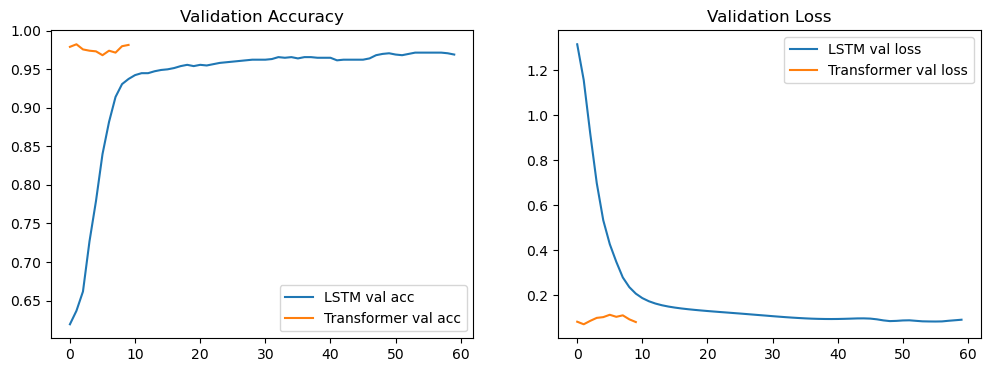

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(history_lstm.history['val_accuracy'], label='LSTM val acc')
axes[0].plot(history_transformer.history['val_accuracy'], label='Transformer val acc')
axes[0].set_title("Validation Accuracy"); axes[0].legend()
axes[1].plot(history_lstm.history['val_loss'], label='LSTM val loss')
axes[1].plot(history_transformer.history['val_loss'], label='Transformer val loss')
axes[1].set_title("Validation Loss"); axes[1].legend()
plt.show()

## Section 9 — Evaluate

--- LSTM + Attention --- Accuracy: 0.9758  Precision: 0.9741  Recall: 0.9728  F1: 0.9734


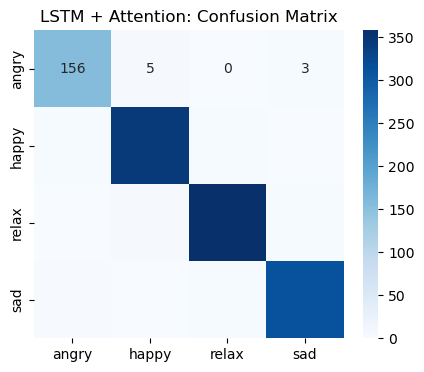

--- Transformer --- Accuracy: 0.9800  Precision: 0.9736  Recall: 0.9816  F1: 0.9773


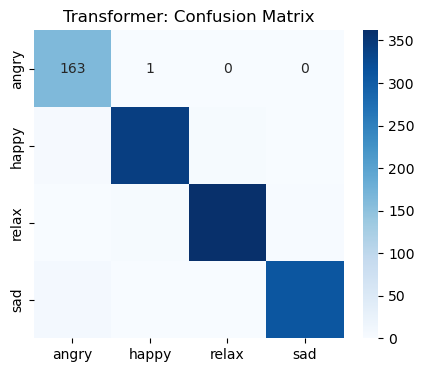

,model,accuracy,precision,recall,f1
0,LSTM + Attention,0.975833,0.974089,0.972758,0.973403
1,Transformer,0.980000,0.973630,0.981584,0.977265


In [20]:
def evaluate_model(model, X_test, y_test, label_encoder, name="Model"):
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=-1)
    y_true_flat, y_pred_flat = y_test.flatten(), y_pred.flatten()
    acc = accuracy_score(y_true_flat, y_pred_flat)
    prec = precision_score(y_true_flat, y_pred_flat, average="macro", zero_division=0)
    rec = recall_score(y_true_flat, y_pred_flat, average="macro", zero_division=0)
    f1 = f1_score(y_true_flat, y_pred_flat, average="macro", zero_division=0)
    print(f"--- {name} --- Accuracy: {acc:.4f}  Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}")
    cm = confusion_matrix(y_true_flat, y_pred_flat)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.title(f"{name}: Confusion Matrix"); plt.show()
    return {"model": name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

results_lstm = evaluate_model(lstm_model, X_test, y_test, label_encoder, "LSTM + Attention")
results_transformer = evaluate_model(transformer_model, X_test, y_test, label_encoder, "Transformer")
comparison_df = pd.DataFrame([results_lstm, results_transformer])
comparison_df

## Section 10 — Preference Drift Score + Validity Check

This is the part that matters most, regardless of the classification-accuracy caveat above.

Average Preference Drift Score: 0.1361177492507354
Mean drift WHEN emotion changes : 0.4358
Mean drift WHEN emotion stays same: 0.0160
Ratio: 27.2x higher when emotion changes


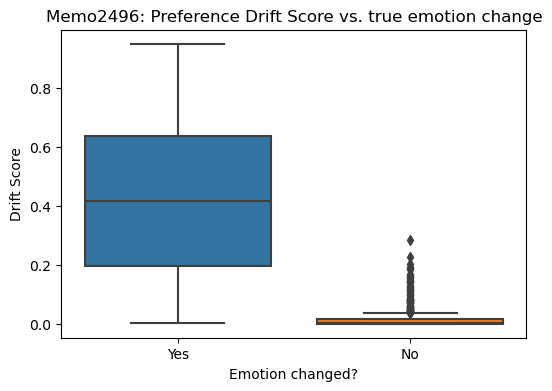

In [21]:
def compute_preference_drift(repr_model, X_data, is_lstm=True):
    if is_lstm:
        representations, attn_weights = repr_model.predict(X_data, verbose=0)
    else:
        representations = repr_model.predict(X_data, verbose=0); attn_weights = None
    n_seq, seq_len, dim = representations.shape
    drift_scores = np.zeros((n_seq, seq_len - 1))
    for i in range(n_seq):
        for t in range(1, seq_len):
            sim = cosine_similarity(representations[i, t-1].reshape(1,-1), representations[i, t].reshape(1,-1))[0,0]
            drift_scores[i, t-1] = 1 - sim
    return drift_scores, representations, attn_weights

drift_scores_test, reprs_test, attn_test = compute_preference_drift(lstm_repr_model, X_test, is_lstm=True)
print("Average Preference Drift Score:", drift_scores_test.mean())

label_changed = (y_test[:, 1:] != y_test[:, :-1]).astype(int)
drift_when_changed = drift_scores_test[label_changed == 1]
drift_when_same = drift_scores_test[label_changed == 0]
print(f"Mean drift WHEN emotion changes : {drift_when_changed.mean():.4f}")
print(f"Mean drift WHEN emotion stays same: {drift_when_same.mean():.4f}")
if drift_when_same.mean() > 0:
    print(f"Ratio: {drift_when_changed.mean() / drift_when_same.mean():.1f}x higher when emotion changes")

plt.figure(figsize=(6,4))
sns.boxplot(data=pd.DataFrame({
    "Drift Score": np.concatenate([drift_when_changed, drift_when_same]),
    "Emotion changed?": ["Yes"]*len(drift_when_changed) + ["No"]*len(drift_when_same)
}), x="Emotion changed?", y="Drift Score")
plt.title("Memo2496: Preference Drift Score vs. true emotion change")
plt.show()

## Section 11 — Save Results (for comparing against your Turkish dataset results)

In [22]:
os.makedirs(RESULTS_DIR, exist_ok=True)
lstm_model.save(f"{RESULTS_DIR}/memo2496_lstm_attention_model.keras")
transformer_model.save(f"{RESULTS_DIR}/memo2496_transformer_model.keras")
comparison_df.to_csv(f"{RESULTS_DIR}/memo2496_model_comparison.csv", index=False)
np.save(f"{RESULTS_DIR}/memo2496_drift_scores_test.npy", drift_scores_test)

summary = {
    "dataset": "memo2496_v2_timeseries_features", "n_songs": len(df), "n_classes": N_CLASSES,
    "lstm_accuracy": results_lstm["accuracy"], "transformer_accuracy": results_transformer["accuracy"],
    "mean_drift_same": drift_when_same.mean(), "mean_drift_changed": drift_when_changed.mean(),
}
pd.DataFrame([summary]).to_csv(f"{RESULTS_DIR}/memo2496_summary.csv", index=False)
print("Saved. Summary:")
for k, v in summary.items():
    print(f"  {k}: {v}")

Saved. Summary:
  dataset: memo2496_v2_timeseries_features
  n_songs: 2496
  n_classes: 4
  lstm_accuracy: 0.9758333333333333
  transformer_accuracy: 0.98
  mean_drift_same: 0.016018785314028054
  mean_drift_changed: 0.43578215441319934
